# Amsterdam test workflow: SAM3 facade classification

In [ ]:
from streetscapes.utils.db_access import get_image, open_project, get_segmentations
db = open_project()

The following commands were used to create the database and segmentation:

```bash
streetscapes config set active_project amsterdam-ems26-small
streetscapes fetch-metadata mapillary 4.861794 52.335496 4.899988 52.366324 --limit 10
streetscapes download-images mapillary
streetscapes segment-images sam3 --prompt "building,brick wall,red brick wall,yellow brick wall,concrete wall,glass wall" --batch-size 20
```

In [ ]:
# enter the run ID of the SAM3 segmentation run you want to use:

RUN_ID = "sam3-2026-08-31T08:32:59.699"

In [ ]:
from geopandas import GeoSeries
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
from streetscapes.utils.property_extraction import poly_to_mask

def get_loc(uuid):
    predicate = db.table("mapillary").image == uuid
    images_filtered = db.table("mapillary").filter(predicate)
    return images_filtered.to_pandas().squeeze()["geometry"]

images = db.table("images").uuid.to_pandas()

result = {}

for i in tqdm(range(len(images))):
    uuid = str(images[i])
    image = get_image(uuid)
    segmentations = get_segmentations(uuid)

    def get_results(segmentations, run_id):
        for seg in segmentations:
            if seg.id == run_id:
                return seg
        return None

    results = get_results(segmentations, RUN_ID)
    results.instances

    h, w, _ = np.asarray(image).shape

    # Note: hardcoded categories (!)
    categories = ("brick facade", "concrete facade", "glass facade")
    masks = {
        "brick facade": np.zeros((h,w), dtype=int),
        "concrete facade": np.zeros((h,w), dtype=int),
        "glass facade": np.zeros((h,w), dtype=int)
    }

    for instance in results.instances:
        if instance.label in masks:
            masks[instance.label] += poly_to_mask(instance.polygon, image)

    # (until we incorporate confidence)
    # facade hierarchy; brick takes presidence over glass, concrete last (in case of overlapping masks)
    # Goal: get non-overlapping boolean masks.
    masks["brick facade"] = np.maximum(masks["brick facade"] - masks["glass facade"], 0)
    masks["concrete facade"] = np.maximum(masks["concrete facade"] - masks["brick facade"] - masks["glass facade"], 0)

    # normalize to 0 - 1
    masks["brick facade"] = np.minimum(masks["brick facade"], 1)
    masks["concrete facade"] = np.minimum(masks["concrete facade"], 1)
    masks["glass facade"] = np.minimum(masks["glass facade"], 1)

    total_pixels = h*w
    bricks = np.sum(masks["brick facade"])/total_pixels
    concrete = np.sum(masks["concrete facade"])/total_pixels
    glass = np.sum(masks["glass facade"])/total_pixels

    # normalize to fraction of facades
    total_frac = bricks + concrete + glass
    if total_frac > 0.05: # at least 5% pixels must be a building
        bricks /= total_frac
        concrete /= total_frac
        glass /= total_frac

        # Get image location
        loc = get_loc(uuid)
        if isinstance(loc, GeoSeries):
            loc = loc[0]

        # store result
        result[loc] = (bricks, concrete, glass)


Now we can plot this as a scatterplot

Text(0.5, 1.0, 'R: brick, G: concrete, B: glass')

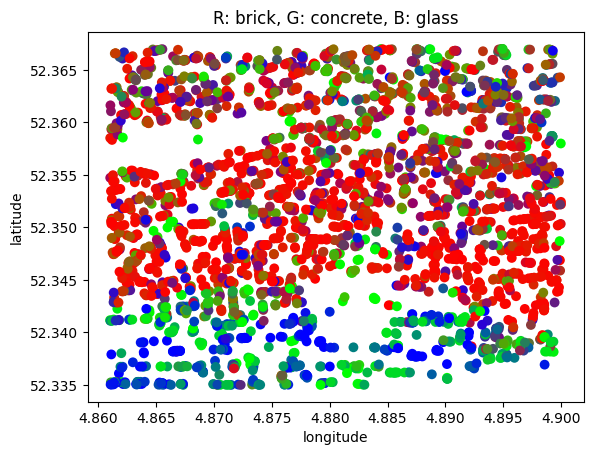

In [20]:
for loc, color in result.items():
    plt.scatter(loc.x, loc.y, s=50, facecolors=color, edgecolors="none")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("R: brick, G: concrete, B: glass")

Scatterplot w/ base map

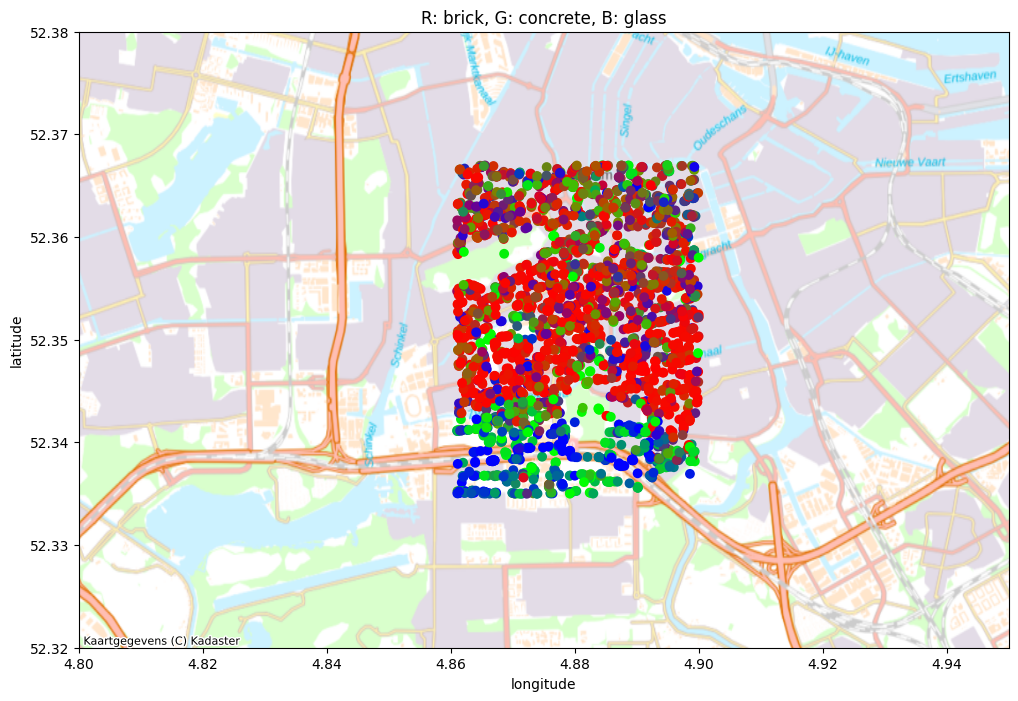

In [26]:
import contextily
fig, ax = plt.subplots(figsize=(12,8))

for loc, color in result.items():
    ax.scatter(loc.x, loc.y, s=50, facecolors=color, edgecolors="none")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("R: brick, G: concrete, B: glass")
ax.set_xlim([4.80, 4.95])
ax.set_ylim([52.32, 52.38])
contextily.add_basemap(ax, crs="EPSG:4326", source=contextily.providers.nlmaps.pastel)


Rasterize the point data:

In [57]:
import math

import geopandas
import rasterio.transform

geom = list(result.keys())
color = list(result.values())
d = {
    "brick": [c[0] for c in color],
    "concrete": [c[1] for c in color],
    "glass": [c[2] for c in color],
    "geometry": geom,
}
gdf = geopandas.GeoDataFrame(d, crs="EPSG:4326")
ams_proj = gdf.to_crs(28992)

bounds = ams_proj.total_bounds
horizontal_resolution = 250
transform = rasterio.transform.from_origin(
    west=bounds[0],
    north=bounds[3],
    xsize=horizontal_resolution,
    ysize=horizontal_resolution
)
transform

import rasterio.features
rows = math.ceil((bounds[3] - bounds[1]) / horizontal_resolution)
cols = math.ceil((bounds[2] - bounds[0]) / horizontal_resolution)
shape = (rows, cols)

g = [(g, v) for g, v in ams_proj[['geometry', 'brick']] \
        .to_numpy() \
        .tolist()]
raster_brick = rasterio.features.rasterize(
    shapes=g,
    out_shape=shape,
    transform=transform,
    fill=np.nan
)
g = [(g, v) for g, v in ams_proj[['geometry', 'concrete']] \
        .to_numpy() \
        .tolist()]
raster_concrete = rasterio.features.rasterize(
    shapes=g,
    out_shape=shape,
    transform=transform,
    fill=np.nan
)
g = [(g, v) for g, v in ams_proj[['geometry', 'glass']] \
        .to_numpy() \
        .tolist()]
raster_glass = rasterio.features.rasterize(
    shapes=g,
    out_shape=shape,
    transform=transform,
    fill=np.nan
)


Plot the rasterized data:

(np.float64(119139.17627525228),
 np.float64(121889.17627525228),
 np.float64(482943.4335834186),
 np.float64(486693.4335834186))

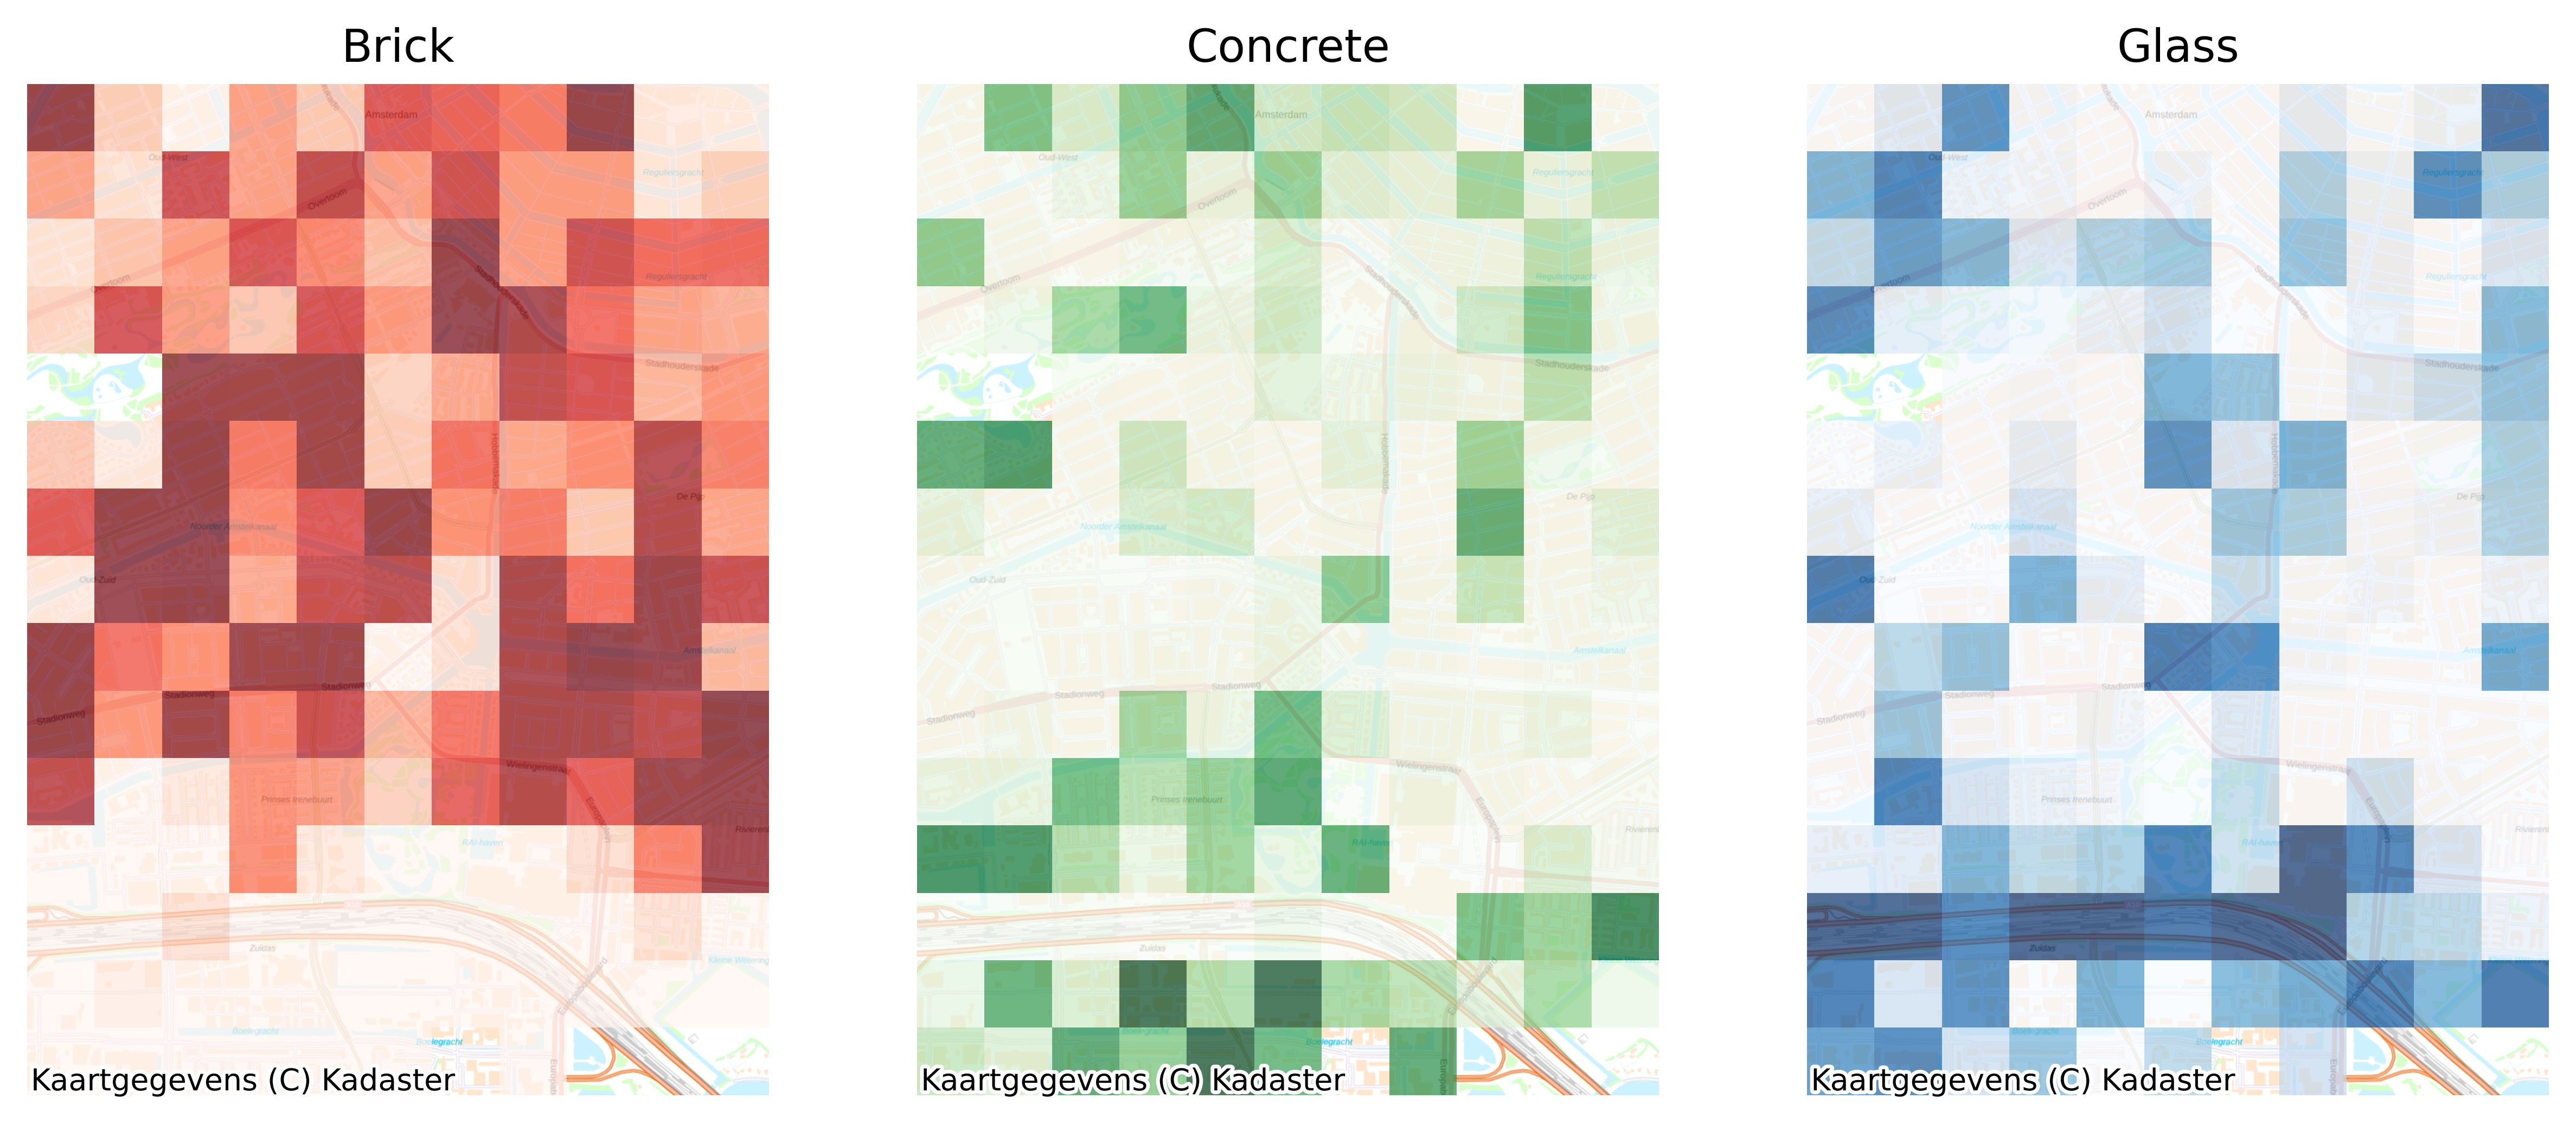

In [ ]:
import rasterio.plot

fig, (ax1, ax2, ax3) = plt.subplots(figsize=(12, 5), ncols=3, sharex=True, sharey=True, dpi=500)

rasterio.plot.show(raster_brick, transform=transform, ax=ax1, vmin=0, vmax=1, cmap="Reds", alpha=0.7)
rasterio.plot.show(raster_concrete, transform=transform, ax=ax2, vmin=0, vmax=1, cmap="Greens", alpha=0.7)
rasterio.plot.show(raster_glass, transform=transform, ax=ax3, vmin=0, vmax=1, cmap="Blues", alpha=0.7)
contextily.add_basemap(ax1, crs=ams_proj.crs, source=contextily.providers.nlmaps.pastel)
contextily.add_basemap(ax2, crs=ams_proj.crs, source=contextily.providers.nlmaps.pastel)
contextily.add_basemap(ax3, crs=ams_proj.crs, source=contextily.providers.nlmaps.pastel)

rasterio.plot.show(raster_brick, transform=transform, ax=ax1, vmin=0, vmax=1, cmap="Reds", alpha=0.7)
rasterio.plot.show(raster_concrete, transform=transform, ax=ax2, vmin=0, vmax=1, cmap="Greens", alpha=0.7)
rasterio.plot.show(raster_glass, transform=transform, ax=ax3, vmin=0, vmax=1, cmap="Blues", alpha=0.7)
ax1.set_title("Brick")
ax2.set_title("Concrete")
ax3.set_title("Glass")
ax1.axis("off")
ax2.axis("off")
ax3.axis("off")
